8982
2246
?periodendeddecember31shrprofit11ctsvsloss24ctsnetprofit??vsloss??revs7??vs7200?reuter3
3
(8982, 1000)
2
(1, 1000) 2
(8982, 46)
2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


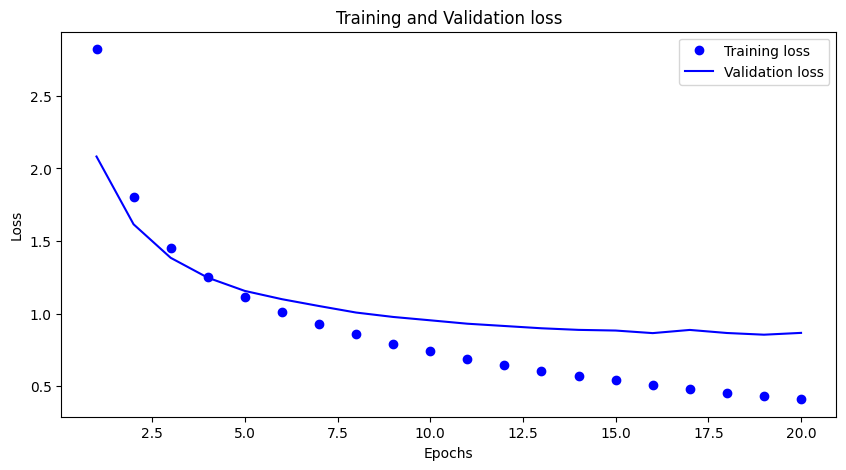


Training second model for 8 epochs...
Epoch 1/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.2802 - loss: 3.3359 - val_accuracy: 0.5580 - val_loss: 2.0568
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6004 - loss: 1.8559 - val_accuracy: 0.6330 - val_loss: 1.5528
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6777 - loss: 1.4677 - val_accuracy: 0.6910 - val_loss: 1.3398
Epoch 4/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7137 - loss: 1.2860 - val_accuracy: 0.7200 - val_loss: 1.2214
Epoch 5/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7351 - loss: 1.1654 - val_accuracy: 0.7340 - val_loss: 1.1469
Epoch 6/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7714 - loss: 1.0277 - val_accuracy: 0.7650 - val_loss: 1.0804
Epoch 7/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7902 - loss: 0.9338 - val_accuracy: 0.7710 - val_loss: 1.0419
Epoch 8/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8009 - loss: 0.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Suppress specific future warnings from Keras/TensorFlow for cleaner output
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from tensorflow.keras.datasets import reuters
from tensorflow.keras import models, layers, utils

# Load the Reuters dataset, limiting to the 1000 most frequent words
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=1000)

print(len(train_data))
print(len(test_data))

# Get the word index and create a reverse index to decode articles
word_index = reuters.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

# Decode the 11th news article (index 10), using '?' for words not in our top 1000
decoded_news = "".join(
    reverse_word_index.get(i - 3, "?") for i in train_data[10]
)
print(decoded_news)
print(train_labels[10])

# Function to vectorize sequences into a one-hot encoding representation
# The dimension must match the num_words set during data loading (1000)
def vectorize_sequences(sequences, dimension=1000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # Only set indices that are within the 1000-word limit
        for index in sequence:
            if index < dimension:
                results[i, index] = 1.0
    return results

# Vectorize training and test data
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

print(x_train.shape)
print(x_train.ndim)

data = [[1, 2, 4, 9, 0]]
x = vectorize_sequences(data)
print(x.shape, x.ndim)

# Convert integer labels to one-hot encoded vectors using Keras utility
# There are 46 different topics in the Reuters dataset
one_hot_train_labels = utils.to_categorical(train_labels)
one_hot_test_labels = utils.to_categorical(test_labels)

print(one_hot_train_labels.shape)
print(one_hot_train_labels.ndim)

# --- Model 1: Initial Training ---

model = models.Sequential()
# CRITICAL FIX: input_shape must match the dimension of our vectorized data (1000), not 10000
model.add(layers.Dense(64, activation='relu', input_shape=(1000,)))
model.add(layers.Dense(46, activation='softmax')) # Output layer for 46 classes

model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy', # Appropriate loss for multi-class classification
    metrics=['accuracy']
)

# Prepare validation data (first 1000 samples)
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]

# Fit the first model
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=0 # Run silently to just capture history
)

# Plotting the training and validation loss
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Model 2: Training a new model for evaluation ---
# Based on the plot above, training for fewer epochs prevents overfitting.

model = models.Sequential()
# CRITICAL FIX: input_shape must match the dimension of our vectorized data (1000)
model.add(layers.Dense(64, activation='relu', input_shape=(1000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))

model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fit the second model with an optimal number of epochs (e.g., 8, based on the plot)
print("\nTraining second model for 8 epochs...")
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=8, # Optimized epochs to avoid overfitting
    batch_size=512,
    validation_data=(x_val, y_val)
)

# Evaluate the final model on the held-out test data
results = model.evaluate(x_test, one_hot_test_labels)

print("\nTest loss, Test accuracy:", results)
